# 🎬 Estatística na prática: medindo a dispersão do catálogo de filmes

Continuação do notebook da Aula 1, com o mesmo dataset de filmes. Não precisa ter rodado o notebook anterior — este já vem completo. É só executar as células na ordem e ler os comentários, sem nenhuma entrega.

## 1. Recriando o banco de dados (igual à Aula 1, com uma coluna nova: bilheteria)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

dados = {
    "titulo": ["Vingadores: Ultimato", "Toy Story", "O Poderoso Chefão", "Coringa",
               "Cidade de Deus", "Interestelar", "A Origem", "Shrek",
               "O Iluminado", "Parasita", "Bacurau", "Divertida Mente",
               "Duna", "Homem-Aranha: Sem Volta Para Casa", "Get Out - Corra!", "Klaus",
               "Tropa de Elite", "Zumbilândia", "Whiplash", "Coco",
               "Corra Que a Policia Vem Ai", "Não Olhe Para Cima", "Barbie", "Oppenheimer"],
    "genero": ["Ação", "Animação", "Drama", "Drama",
               "Drama", "Ficção Científica", "Ficção Científica", "Animação",
               "Terror", "Drama", "Ficção Científica", "Animação",
               "Ficção Científica", "Ação", "Terror", "Animação",
               "Ação", "Comédia", "Drama", "Animação",
               "Comédia", "Comédia", "Comédia", "Drama"],
    "classificacao_indicativa": ["12", "Livre", "16", "16",
                                  "18", "10", "12", "Livre",
                                  "16", "16", "16", "Livre",
                                  "12", "12", "16", "Livre",
                                  "18", "14", "12", "Livre",
                                  "12", "12", "10", "14"],
    "ano": [2019, 1995, 1972, 2019, 2002, 2014, 2010, 2001, 1980, 2019,
            2019, 2015, 2021, 2021, 2017, 2019, 2007, 2009, 2014, 2017,
            1981, 2021, 2023, 2023],
    "duracao_minutos": [181, 81, 175, 122, 130, 169, 148, 90, 146, 132,
                         131, 95, 155, 148, 104, 96, 115, 88, 107, 105,
                         94, 138, 114, 180],
    "nota_publico": [8.4, 8.3, 9.2, 8.4, 8.6, 8.7, 8.8, 7.9, 8.4, 8.6,
                      7.0, 8.1, 8.0, 8.3, 7.7, 7.5, 7.7, 7.6, 8.5, 8.4,
                      7.7, 7.2, 6.9, 8.4],
    "bilheteria_milhoes": [2797, 373, 246, 1074, 30, 701, 836, 484, 47, 258,
                            1.2, 858, 434, 1922, 255, 3.4, 25, 75, 13, 814,
                            36, 787, 1447, 950],
}

df = pd.DataFrame(dados)
df.head(10)

,titulo,genero,classificacao_indicativa,ano,duracao_minutos,nota_publico,bilheteria_milhoes
0,Vingadores: Ultimato,Ação,12,2019,181,8.4,2797.0
1,Toy Story,Animação,Livre,1995,81,8.3,373.0
2,O Poderoso Chefão,Drama,16,1972,175,9.2,246.0
3,Coringa,Drama,16,2019,122,8.4,1074.0
4,Cidade de Deus,Drama,18,2002,130,8.6,30.0
5,Interestelar,Ficção Científica,10,2014,169,8.7,701.0
6,A Origem,Ficção Científica,12,2010,148,8.8,836.0
7,Shrek,Animação,Livre,2001,90,7.9,484.0
8,O Iluminado,Terror,16,1980,146,8.4,47.0
9,Parasita,Drama,16,2019,132,8.6,258.0


## 2. Desvio médio e variância

Vamos calcular à mão (com o Python fazendo a conta) o desvio médio e a variância da nota do público — os mesmos conceitos da aula, agora com dado real.

In [2]:
nota = df["nota_publico"]
media = nota.mean()

desvios = nota - media
desvio_medio = desvios.abs().mean()
variancia = (desvios ** 2).mean()

print(f"Média:        {media:.2f}")
print(f"Desvio médio: {desvio_medio:.2f}")
print(f"Variância:    {variancia:.2f}")

Média:        8.10
Desvio médio: 0.48
Variância:    0.33


**Repare**: `pandas` já tem uma função pronta para variância (`.var()`), mas ela usa por padrão o divisor n-1 (variância amostral, que você ainda vai ver mais pra frente no curso) em vez de n. Por isso calculamos "na mão" aqui, pra bater exatamente com a definição vista em aula.

## 3. Quantis empíricos

Vamos calcular o 1º quartil (Q1), a mediana (Q2) e o 3º quartil (Q3) da nota do público.

In [3]:
q1 = nota.quantile(0.25)
q2 = nota.quantile(0.50)
q3 = nota.quantile(0.75)
iqr = q3 - q1

print(f"Q1 (1º quartil): {q1:.2f}")
print(f"Q2 (mediana):    {q2:.2f}")
print(f"Q3 (3º quartil): {q3:.2f}")
print(f"IQR (Q3 - Q1):   {iqr:.2f}")

Q1 (1º quartil): 7.70
Q2 (mediana):    8.30
Q3 (3º quartil): 8.43
IQR (Q3 - Q1):   0.73


## 4. Box plot

O box plot desenha exatamente os quartis que acabamos de calcular: a caixa vai de Q1 a Q3, a linha no meio é a mediana, e os "bigodes" mostram até onde os dados vão sem contar outliers.

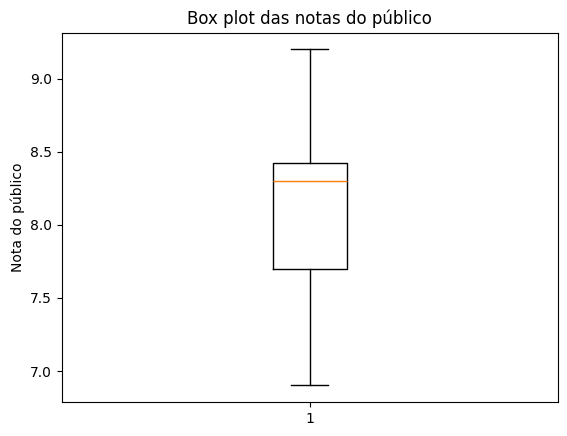

In [4]:
plt.boxplot(nota)
plt.ylabel("Nota do público")
plt.title("Box plot das notas do público")
plt.show()

## 5. Simetria: comparando uma variável simétrica com uma assimétrica

Vamos comparar o histograma da nota do público (mais simétrico) com o histograma da bilheteria em milhões de dólares (bem assimétrico — a maioria dos filmes fatura pouco, e uns poucos blockbusters puxam a cauda para a direita).

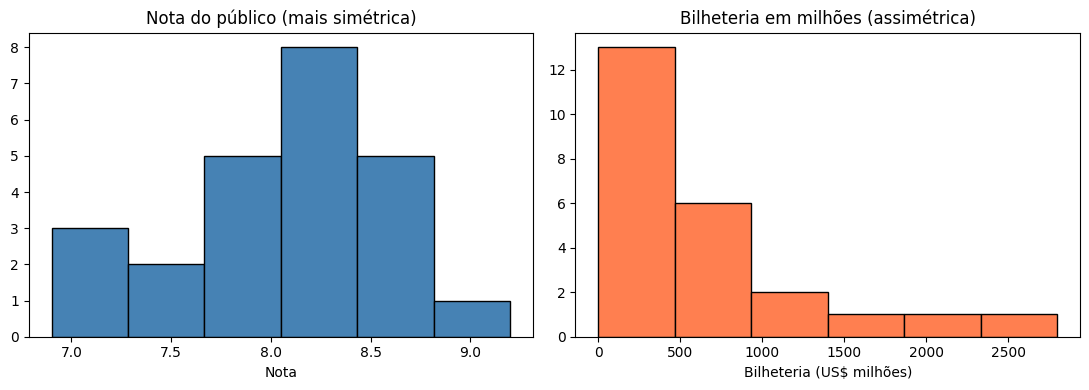

In [5]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))

eixos[0].hist(df["nota_publico"], bins=6, color="steelblue", edgecolor="black")
eixos[0].set_title("Nota do público (mais simétrica)")
eixos[0].set_xlabel("Nota")

eixos[1].hist(df["bilheteria_milhoes"], bins=6, color="coral", edgecolor="black")
eixos[1].set_title("Bilheteria em milhões (assimétrica)")
eixos[1].set_xlabel("Bilheteria (US$ milhões)")

plt.tight_layout()
plt.show()

In [6]:
media_bilheteria = df["bilheteria_milhoes"].mean()
mediana_bilheteria = df["bilheteria_milhoes"].median()

print(f"Bilheteria — média:   {media_bilheteria:.1f} milhões")
print(f"Bilheteria — mediana: {mediana_bilheteria:.1f} milhões")

Bilheteria — média:   602.8 milhões
Bilheteria — mediana: 403.5 milhões


**Repare a diferença enorme entre média e mediana da bilheteria** — isso é a marca registrada de uma distribuição assimétrica (poucos filmes "puxando" a média para cima). Compare com a nota do público, onde média e mediana ficam bem mais próximas. É por isso que, para dados muito assimétricos (como renda, bilheteria, preço de imóvel), a **mediana** costuma ser uma medida mais representativa do que a média.

## 6. Box plot lado a lado — comparando os gêneros

Por curiosidade: será que filmes de gêneros diferentes têm notas parecidas, ou algum gênero se destaca?

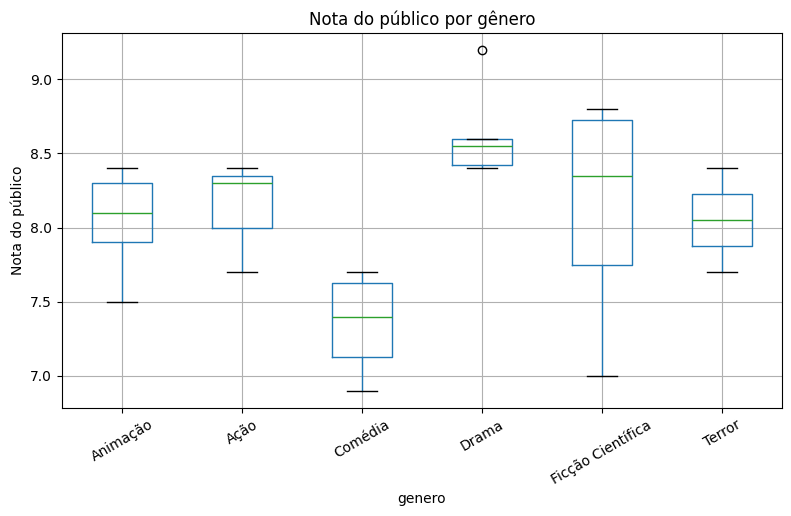

In [7]:
df.boxplot(column="nota_publico", by="genero", figsize=(9, 5), rot=30)
plt.title("Nota do público por gênero")
plt.suptitle("")
plt.ylabel("Nota do público")
plt.show()

## Para fechar

Com 6 linhas de código a gente comparou a dispersão e a simetria de duas variáveis bem diferentes (nota vs. bilheteria) — a mesma análise, feita à mão, levaria bem mais tempo e sujeitaria a mais erro de conta. Isso é parte do que torna ferramentas como o Python tão usadas em ciência de dados: repetir a mesma análise para dezenas de variáveis diferentes sem custo extra de tempo.